In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
print("ready")

ready


In [4]:
class VolatileEnvironment:
    def __init__(self, switch_prob=0.1, seed=42):
        """
        Two-state volatile environment.
        switch_prob: probability of reward contingency 
                     switching each trial
        """
        np.random.seed(seed)
        self.switch_prob = switch_prob
        self.rewarded_action = 0
        self.trial = 0
        self.history = []
    
    def step(self, action):
        """
        Agent takes action (0 or 1).
        Returns reward and whether switch occurred.
        """
        switched = False
        if np.random.random() < self.switch_prob:
            self.rewarded_action = 1 - self.rewarded_action
            switched = True
        
        if action == self.rewarded_action:
            reward = 1 if np.random.random() < 0.8 else 0
        else:
            reward = 1 if np.random.random() < 0.2 else 0
        
        self.trial += 1
        self.history.append({
            'trial': self.trial,
            'action': action,
            'reward': reward,
            'rewarded_action': self.rewarded_action,
            'switched': switched
        })
        
        return reward, switched
    
    def reset(self):
        self.rewarded_action = 0
        self.trial = 0
        self.history = []

print("VolatileEnvironment defined")

# Volatile Environment Class -> Environment with a Hidden State ( Action that pays off ), it is binary so it could either be 0 or 1.
# The Agent Created cannot see the Hidden State but only learn from the Environment.
# Switch_prob = 0.1 -> 10% chance of the environment switching Hidden State on each trial. This aspect makes the world volatile, it keeps changing without a warning.

# step(action) -> The action of each trial the Agent chooses either 0 or 1.
# If it chooses currently rewarded action (e.g. 1 if Hidden state is 1) it has a 80% probability to receive the reward. If not it has a 20% probability.

# The 20% and 80% rather than 0% and 100% is important to the idea that the Agent can’t know the state only after a trial. -> One bad outcome does not mean the world has changed. One good outcome does not mean the Agent is right about the Hidden State.
# The idea is the choice should be based on accumulated experience, which is exactly what makes uncertainty hard.

VolatileEnvironment defined


In [5]:
env = VolatileEnvironment(switch_prob=0.1, seed=42)

for i in range(30):
    reward, switched = env.step(action=0)
    if switched:
        print(f"Trial {i+1}: *** SWITCH *** reward={reward}, rewarded_action={env.rewarded_action}")
    else:
        print(f"Trial {i+1}: reward={reward}, rewarded_action={env.rewarded_action}")

# Environment choices are always 0, this cell is a test method. -> Actual test before adding an Agent.
# This acts only as the confirmation for the fact that the Hidden State Flips happen, before starting the implementation of Agents in the Environment.

Trial 1: reward=0, rewarded_action=0
Trial 2: reward=1, rewarded_action=0
Trial 3: reward=1, rewarded_action=0
Trial 4: *** SWITCH *** reward=0, rewarded_action=1
Trial 5: reward=0, rewarded_action=1
Trial 6: *** SWITCH *** reward=0, rewarded_action=0
Trial 7: reward=1, rewarded_action=0
Trial 8: reward=1, rewarded_action=0
Trial 9: reward=1, rewarded_action=0
Trial 10: reward=1, rewarded_action=0
Trial 11: reward=1, rewarded_action=0
Trial 12: reward=1, rewarded_action=0
Trial 13: reward=1, rewarded_action=0
Trial 14: reward=1, rewarded_action=0
Trial 15: reward=1, rewarded_action=0
Trial 16: reward=1, rewarded_action=0
Trial 17: *** SWITCH *** reward=0, rewarded_action=1
Trial 18: reward=0, rewarded_action=1
Trial 19: reward=1, rewarded_action=1
Trial 20: reward=0, rewarded_action=1
Trial 21: reward=0, rewarded_action=1
Trial 22: *** SWITCH *** reward=0, rewarded_action=0
Trial 23: reward=1, rewarded_action=0
Trial 24: reward=1, rewarded_action=0
Trial 25: reward=1, rewarded_action=0

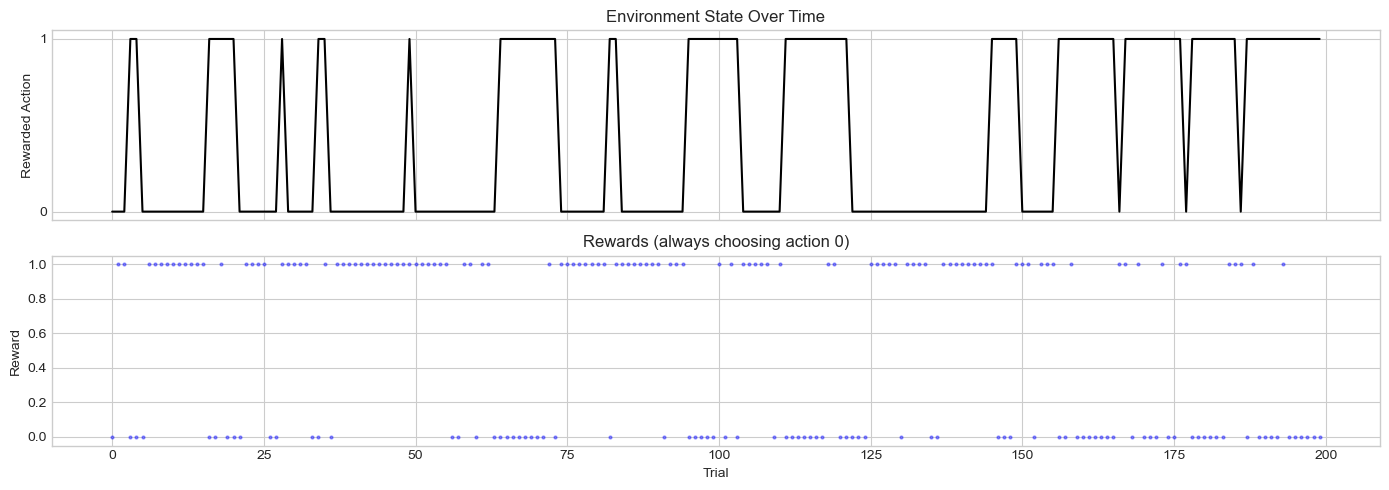

In [6]:
env2 = VolatileEnvironment(switch_prob=0.1, seed=42)

trials = 200
rewarded_actions = []
rewards = []

for i in range(trials):
    reward, switched = env2.step(action=0)
    rewarded_actions.append(env2.rewarded_action)
    rewards.append(reward)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

ax1.plot(rewarded_actions, 'k-', lw=1.5)
ax1.set_ylabel('Rewarded Action')
ax1.set_yticks([0, 1])
ax1.set_title('Environment State Over Time')

ax2.plot(rewards, 'b.', alpha=0.4, markersize=4)
ax2.set_ylabel('Reward')
ax2.set_xlabel('Trial')
ax2.set_title('Rewards (always choosing action 0)')

plt.tight_layout()
plt.show()

# This cells sole purpose is being a plot that illustrates the change of Hidden State and Rewards by each trial.